## 模型建立

In [1]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses, optimizers, callbacks
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置随机种子 (Reproducibility)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. 读取上一阶段保存的数据
data_path = "../data/modeling_data_ready.pkl"
try:
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    print("✅ 数据加载成功！")
except FileNotFoundError:
    print("❌ 错误：未找到数据文件，请检查路径。")

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

# 同时也读取 SMOTE 数据（用于后续的对比基准模型，SDAE主要用原始数据）
X_train_smote = data['X_train_smote']
y_train_smote = data['y_train_smote']

# 获取输入维度
input_dim = X_train.shape[1]
print(f"输入特征维度: {input_dim}")
print(f"训练集形状: {X_train.shape}")

e:\miniconda3\envs\GradProject\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


✅ 数据加载成功！
输入特征维度: 15
训练集形状: (4929, 15)



=== 开始预训练 SDAE (无监督学习阶段) ===
✅ SDAE 预训练完成。


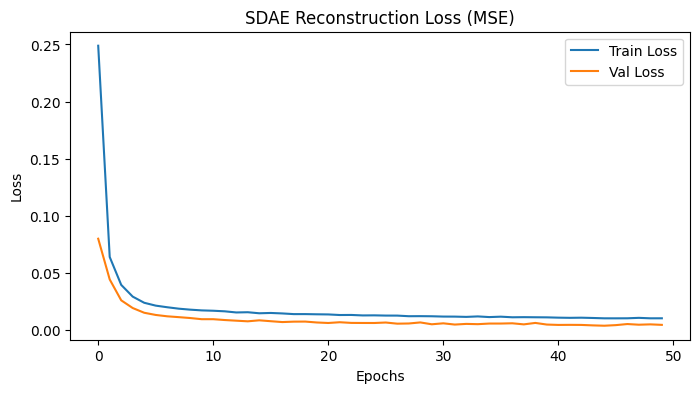

In [2]:
# --- 4.2.1 SDAE 模型定义 ---

def build_sdae(input_dim, encoding_dim=16):
    """
    构建堆叠降噪自编码器 (Stacked Denoising Autoencoder)
    """
    # 输入层
    input_layer = layers.Input(shape=(input_dim,))
    
    # 1. 降噪层 (加入高斯噪声，强迫模型学习鲁棒特征)
    # stddev=0.1 表示加入轻微噪声
    masked_input = layers.GaussianNoise(0.1)(input_layer)
    
    # 2. 编码器 (Encoder) - 压缩特征
    # 使用 selu 激活函数实现自归一化，适合深层网络
    encoded = layers.Dense(64, activation='selu')(masked_input)
    encoded = layers.Dense(32, activation='selu')(encoded)
    
    # Latent Space (瓶颈层)
    latent = layers.Dense(encoding_dim, activation='selu', name='latent_layer')(encoded)
    
    # 3. 解码器 (Decoder) - 重构特征
    decoded = layers.Dense(32, activation='selu')(latent)
    decoded = layers.Dense(64, activation='selu')(decoded)
    # 输出层：尝试重构原始输入
    output_layer = layers.Dense(input_dim, activation='linear')(decoded)
    
    # 构建完整 Autoencoder
    autoencoder = keras.Model(inputs=input_layer, outputs=output_layer, name="SDAE")
    
    # 构建独立的 Encoder (用于后续特征提取)
    encoder = keras.Model(inputs=input_layer, outputs=latent, name="SDAE_Encoder")
    
    return autoencoder, encoder

# --- 训练 SDAE ---
print("\n=== 开始预训练 SDAE (无监督学习阶段) ===")

# 初始化模型
autoencoder, sdae_encoder = build_sdae(input_dim, encoding_dim=16)

# 编译模型：使用 MSE 损失函数 (重构误差)
autoencoder.compile(optimizer='adam', loss='mse')

# 训练：使用 X_train 本身作为目标 (自监督)
# 既然是无监督，其实可以用 X_train + X_test 一起练，但为了严谨我们只用 X_train
history_sdae = autoencoder.fit(
    X_train, X_train,
    epochs=50,             # 训练轮数
    batch_size=64,         # 批次大小
    shuffle=True,
    validation_data=(X_val, X_val),
    verbose=0              # 静默模式，不刷屏
)

print("✅ SDAE 预训练完成。")

# 可视化重构误差下降曲线
plt.figure(figsize=(8, 4))
plt.plot(history_sdae.history['loss'], label='Train Loss')
plt.plot(history_sdae.history['val_loss'], label='Val Loss')
plt.title('SDAE Reconstruction Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

原始训练集: (4929, 15), 纯正常样本训练集: (3621, 15)
✅ 只基于正常样本的 SDAE 训练完成
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


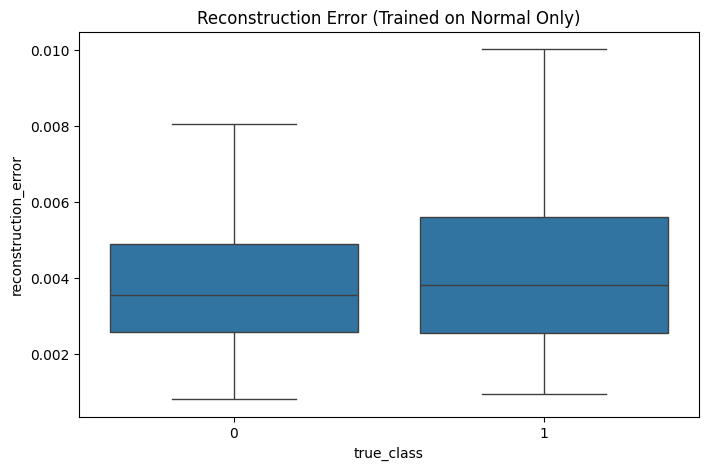

In [8]:
# === 改进代码：只用正常样本训练 ===

# 1. 筛选正常样本
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]

print(f"原始训练集: {X_train.shape}, 纯正常样本训练集: {X_train_normal.shape}")

# 2. 重新构建模型 (保持结构不变)
autoencoder_v2, encoder_v2 = build_sdae(input_dim, encoding_dim=16)
autoencoder_v2.compile(optimizer='adam', loss='mse')

# 3. 训练 (注意：输入和标签都是 X_train_normal)
history_v2 = autoencoder_v2.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_data=(X_val_normal, X_val_normal),
    verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

print("✅ 只基于正常样本的 SDAE 训练完成")

# --- 再次评估效果 ---
# 预测测试集 (测试集包含正常和欺诈)
X_test_pred_v2 = autoencoder_v2.predict(X_test)
mse_v2 = np.mean(np.power(X_test_pred_v2 - X_test, 2), axis=1)

error_df_v2 = pd.DataFrame({'reconstruction_error': mse_v2, 'true_class': y_test})

# 画图对比
plt.figure(figsize=(8, 5))
sns.boxplot(x='true_class', y='reconstruction_error', data=error_df_v2, showfliers=False)
plt.title('Reconstruction Error (Trained on Normal Only)')
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
重构误差统计描述：
            count      mean       std       min       25%       50%       75%  \
true_class                                                                      
0           518.0  0.004011  0.002210  0.000800  0.002560  0.003550  0.004884   
1           187.0  0.004520  0.002814  0.000946  0.002533  0.003815  0.005607   

                 max  
true_class            
0           0.022319  
1           0.016162  


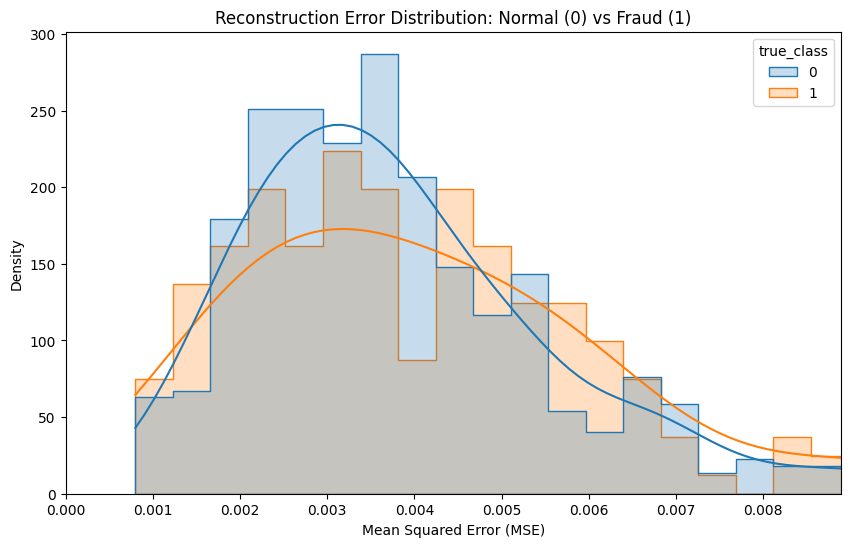

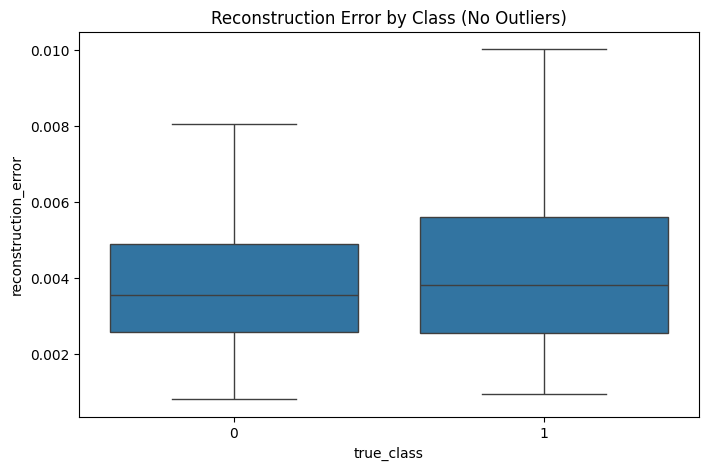

In [9]:
# 1. 使用 Autoencoder 对测试集进行预测（重构）
X_test_pred = autoencoder_v2.predict(X_test)

# 2. 计算每个样本的均方误差 (MSE)
# axis=1 表示对每个样本的所有特征求平均
test_mae = np.mean(np.abs(X_test_pred - X_test), axis=1)
test_mse = np.mean(np.power(X_test_pred - X_test, 2), axis=1)

# 创建一个 DataFrame 方便画图
error_df = pd.DataFrame({
    'reconstruction_error': test_mse,
    'true_class': y_test
})

print("重构误差统计描述：")
print(error_df.groupby('true_class')['reconstruction_error'].describe())

# 3. 可视化：正常交易 vs 欺诈交易 的重构误差分布
plt.figure(figsize=(10, 6))
sns.histplot(data=error_df, x='reconstruction_error', hue='true_class', 
             bins=50, kde=True, element="step", stat="density", common_norm=False)
plt.title('Reconstruction Error Distribution: Normal (0) vs Fraud (1)')
plt.xlabel('Mean Squared Error (MSE)')
plt.xlim(0, error_df['reconstruction_error'].quantile(0.95)) # 限制x轴范围以防极值影响观察
plt.show()

# 4. 箱线图对比（更能看清中位数的差异）
plt.figure(figsize=(8, 5))
sns.boxplot(x='true_class', y='reconstruction_error', data=error_df, showfliers=False)
plt.title('Reconstruction Error by Class (No Outliers)')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 200 samples in 0.000s...
[t-SNE] Computed neighbors for 200 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 200 / 200
[t-SNE] Mean sigma: 1.308312
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.299686
[t-SNE] KL divergence after 1000 iterations: 0.658982


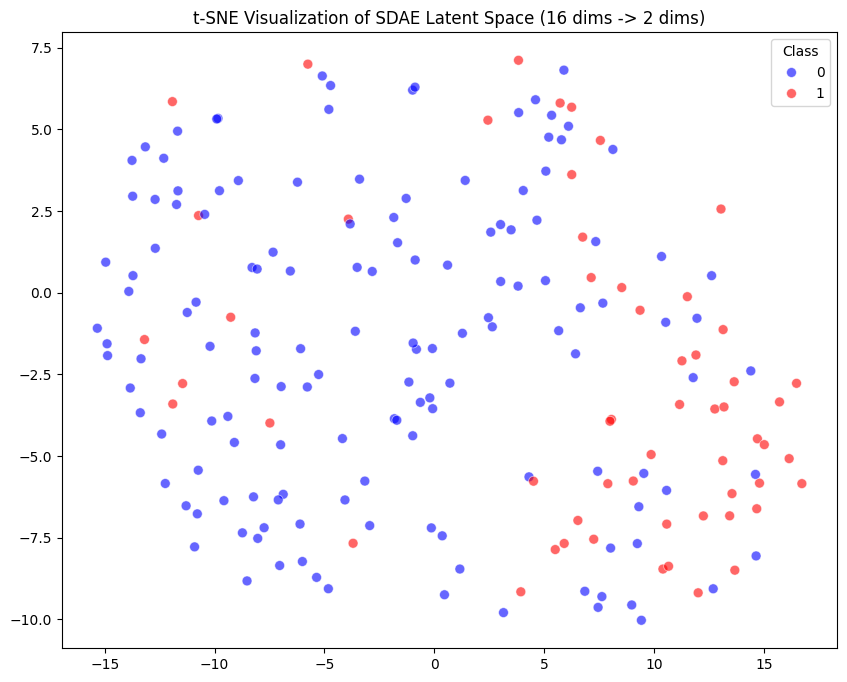

In [10]:
from sklearn.manifold import TSNE

# 1. 获取编码后的特征 (Latent Representation)
# 为了速度，我们可以只取测试集的一部分样本进行可视化（例如 2000 个）
n_samples_viz = 200
indices = np.random.choice(range(len(X_test)), n_samples_viz, replace=False)

X_test_subset = X_test.iloc[indices] if hasattr(X_test, 'iloc') else X_test[indices]
y_test_subset = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]

# 获取 16维 的编码特征
encoded_features = encoder_v2.predict(X_test_subset)

# 2. 使用 t-SNE 降维到 2D
tsne = TSNE(n_components=2, random_state=SEED, verbose=1, perplexity=30)
tsne_results = tsne.fit_transform(encoded_features)

# 3. 可视化
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_results[:, 0], y=tsne_results[:, 1],
    hue=y_test_subset,
    palette=["blue", "red"],
    alpha=0.6,
    s=50
)
plt.title('t-SNE Visualization of SDAE Latent Space (16 dims -> 2 dims)')
plt.legend(title='Class')
plt.show()

In [3]:
# --- 4.2.2 & 4.2.3 集成欠采样 + 代价敏感分类 ---

from sklearn.utils import resample

# 定义集成模型的数量 (Bagging Estimators)
N_ESTIMATORS = 10 

# 存储所有训练好的子模型
ensemble_models = []

# 准备数据索引
# 多数类 (y=0) 和 少数类 (y=1)
X_train_np = X_train.values
y_train_np = y_train.values

# 分离索引
idx_majority = np.where(y_train_np == 0)[0]
idx_minority = np.where(y_train_np == 1)[0]

print(f"\n=== 开始训练集成模型 (共 {N_ESTIMATORS} 个基分类器) ===")
print(f"少数类样本数: {len(idx_minority)}")
print(f"多数类样本数: {len(idx_majority)} (将被欠采样)")

# 定义基分类器构建函数 (简单的 MLP)
def build_classifier(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3), # 防止过拟合
        layers.Dense(16, activation='relu'),
        # 输出层：Sigmoid 用于二分类
        layers.Dense(1, activation='sigmoid') 
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- 循环训练 (Bagging Loop) ---
for i in range(N_ESTIMATORS):
    # 1. 欠采样策略：随机抽取与少数类等量的多数类样本
    idx_majority_downsampled = resample(idx_majority, 
                                        replace=False,     # 不放回抽样
                                        n_samples=len(idx_minority), # 数量对齐
                                        random_state=SEED + i) # 每次随机种子不同
    
    # 2. 拼接数据 (形成平衡的子训练集)
    idx_balanced = np.concatenate([idx_minority, idx_majority_downsampled])
    X_subset_raw = X_train_np[idx_balanced]
    y_subset = y_train_np[idx_balanced]
    
    # 3. SDAE 特征变换 (Feature Transformation)
    # 使用预训练好的 encoder 提取特征，不进行梯度更新 (Freeze)
    X_subset_latent = sdae_encoder.predict(X_subset_raw, verbose=0)
    
    # 4. 代价敏感设置 (Cost-Sensitive)
    # 虽然已经是平衡子集，但为了进一步强化流失识别 (4.2.3)，我们可以加权
    # 这里设置 w1 = 1.2, w0 = 1.0 (轻微向流失倾斜)
    # 如果想用 CLTV 加权，可以在 fit 的 sample_weight 参数里传
    class_weights = {0: 1.0, 1: 1.2} 
    
    # 5. 训练子分类器
    clf = build_classifier(input_dim=16) # 输入是 SDAE 的 encoding_dim
    clf.fit(X_subset_latent, y_subset, 
            epochs=30, 
            batch_size=32, 
            class_weight=class_weights, # 代价敏感关键点
            verbose=0)
    
    ensemble_models.append(clf)
    print(f"子模型 {i+1}/{N_ESTIMATORS} 训练完成")

print("✅ 集成模型构建完毕。")


=== 开始训练集成模型 (共 10 个基分类器) ===
少数类样本数: 1308
多数类样本数: 3621 (将被欠采样)
子模型 1/10 训练完成
子模型 2/10 训练完成
子模型 3/10 训练完成
子模型 4/10 训练完成
子模型 5/10 训练完成
子模型 6/10 训练完成
子模型 7/10 训练完成
子模型 8/10 训练完成
子模型 9/10 训练完成
子模型 10/10 训练完成
✅ 集成模型构建完毕。



=== 最终模型评估 (测试集) ===

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       518
           1       0.52      0.81      0.63       187

    accuracy                           0.75       705
   macro avg       0.72      0.77      0.72       705
weighted avg       0.81      0.75      0.76       705

AUC-ROC Score: 0.8527


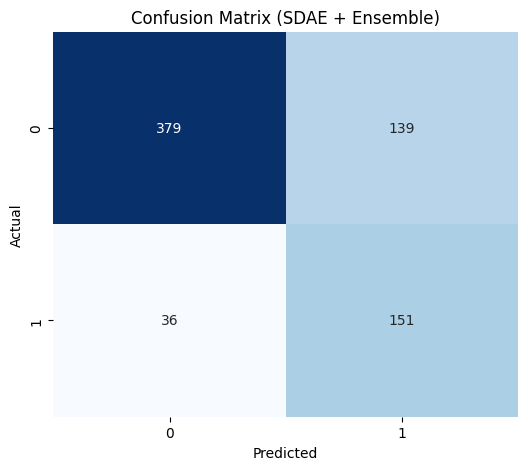

🚀 核心指标 - 流失用户召回率 (Recall): 80.75%


In [4]:
# --- 模型评估逻辑 ---

def ensemble_predict(encoder, models, X_input):
    """
    集成预测函数：
    1. 使用 Encoder 转换特征
    2. 让所有子模型预测
    3. 取平均值 (Soft Voting)
    """
    # 1. 特征变换
    X_latent = encoder.predict(X_input, verbose=0)
    
    # 2. 收集所有预测结果
    predictions = []
    for model in models:
        pred = model.predict(X_latent, verbose=0)
        predictions.append(pred)
    
    # 3. 取平均
    avg_pred = np.mean(predictions, axis=0)
    return avg_pred

# --- 在测试集上评估 ---
print("\n=== 最终模型评估 (测试集) ===")

# 获取预测概率
y_pred_proba = ensemble_predict(sdae_encoder, ensemble_models, X_test)
# 获取预测类别 (阈值默认 0.5)
y_pred_class = (y_pred_proba > 0.5).astype(int)

# 1. 输出分类报告 (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# 2. 计算 AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc:.4f}")

# 3. 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (SDAE + Ensemble)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. 重点关注：流失用户召回率 (Recall of Class 1)
recall_churn = cm[1,1] / (cm[1,0] + cm[1,1])
print(f"🚀 核心指标 - 流失用户召回率 (Recall): {recall_churn:.2%}")